# Lab Day 1 — Neural network

Họ tên: **Hoàng Trung Anh** · MSSV: **2A202602521**

Outputs lưu từ các kết quả thực chạy trên Google Colab/Tesla T4. Notebook được đóng gói lại từ JSON/PNG của lượt chạy; Restart & Run All sẽ huấn luyện lại và thay output. Các giả thuyết dưới đây được bổ sung sau lượt chạy đầu, không phải dự đoán được ghi trước thí nghiệm.

Mở notebook cùng thư mục `submission_2A202602521/code/`; nếu chạy trong runtime Colab mới, tải ZIP bài nộp lên khi được yêu cầu. Chọn GPU T4. Dữ liệu và scripts lấy từ repo của bài.

## Part 0 — Chuẩn bị môi trường và dữ liệu

Giữ split metadata của bài. Validation 20% train, stratify, seed 42. Chỉ dùng train để fit chuẩn hoá 10 cột số. Không dùng eval để chọn cấu hình.

In [1]:
import os, sys, json, subprocess, zipfile
from pathlib import Path
import torch
from IPython.display import Image, display

start = Path.cwd()
candidates = [start, *start.parents, Path('/content/K4-Track4-Day1-Neuralnetwork')]
repo = next((p for p in candidates if (p/'scripts/evaluate.py').exists() and (p/'data').exists()), None)
if repo is None:
    repo = Path('/content/K4-Track4-Day1-Neuralnetwork')
    subprocess.run(['git','clone','https://github.com/trungKoiKa/K4-Track4-Day1-Neuralnetwork.git',str(repo)], check=True)
out = repo/'submission_2A202602521'
if not (out/'code/finish_colab.py').exists():
    from google.colab import files
    print('Upload submission_2A202602521.zip (the completed submission code).')
    uploaded = files.upload()
    archive = next(name for name in uploaded if name.endswith('.zip'))
    with zipfile.ZipFile(archive) as z:
        for member in z.infolist():
            target = (repo/member.filename).resolve()
            if repo.resolve() not in target.parents and target != repo.resolve():
                raise ValueError('Unsafe ZIP path')
        z.extractall(repo)
os.chdir(repo)
sys.path.insert(0,str(out/'code'))
if not (repo/'data/processed/train.npz').exists():
    subprocess.run([sys.executable,'scripts/split_data.py'],check=True)
from data import prepare_data
from model import MLP, count_params
from train import run_experiment
from plots import plot_run
from results_table import save_result
device = 'cuda' if torch.cuda.is_available() else 'cpu'
data = prepare_data(device)
print('GPU:', torch.cuda.get_device_name(0) if device == 'cuda' else 'CPU')
print('PyTorch:', torch.__version__)
print('Parameters:', count_params(MLP()))
print('Logits:', tuple(MLP().to(device)(data['X_tr'][:20]).shape))


train=371,847; val=92,962; eval=116,203; majority-val accuracy=0.4876
GPU: Tesla T4
PyTorch: 2.11.0+cu130
Parameters: 47879
Logits: (20, 7)


In [2]:
def execute(cfg):
    result = run_experiment(cfg, data)
    save_result(result, str(out/'results'))
    figure = out/'figures'/f"{cfg['exp_id']}.png"
    plot_run(result, str(figure))
    print(json.dumps(result['summary'], indent=2))
    display(Image(filename=str(figure)))
    return result
completed = []


## Part 1 — Baseline và độ nhiễu

M-base 54→256→128→7, CE, AdamW lr=0.001, He, batch=2048, 20 epoch. Lặp seed 1, 2, 3; checkpoint chọn theo val loss nhỏ nhất. Ngưỡng nhiễu: 2 × độ lệch chuẩn mẫu macro-F1 validation baseline.

{
  "step0_loss": 2.269061788393712,
  "best_val_loss": 0.28759079256888903,
  "best_epoch": 20,
  "final_train_loss": 0.2739207979441141,
  "final_val_loss": 0.28759079256888903,
  "val_acc": 0.8839310686086788,
  "val_macro_f1": 0.8105385838093785,
  "time_per_epoch_s": 0.440718332799986,
  "peak_mem_MB": 161.13525390625,
  "diverged": false
}


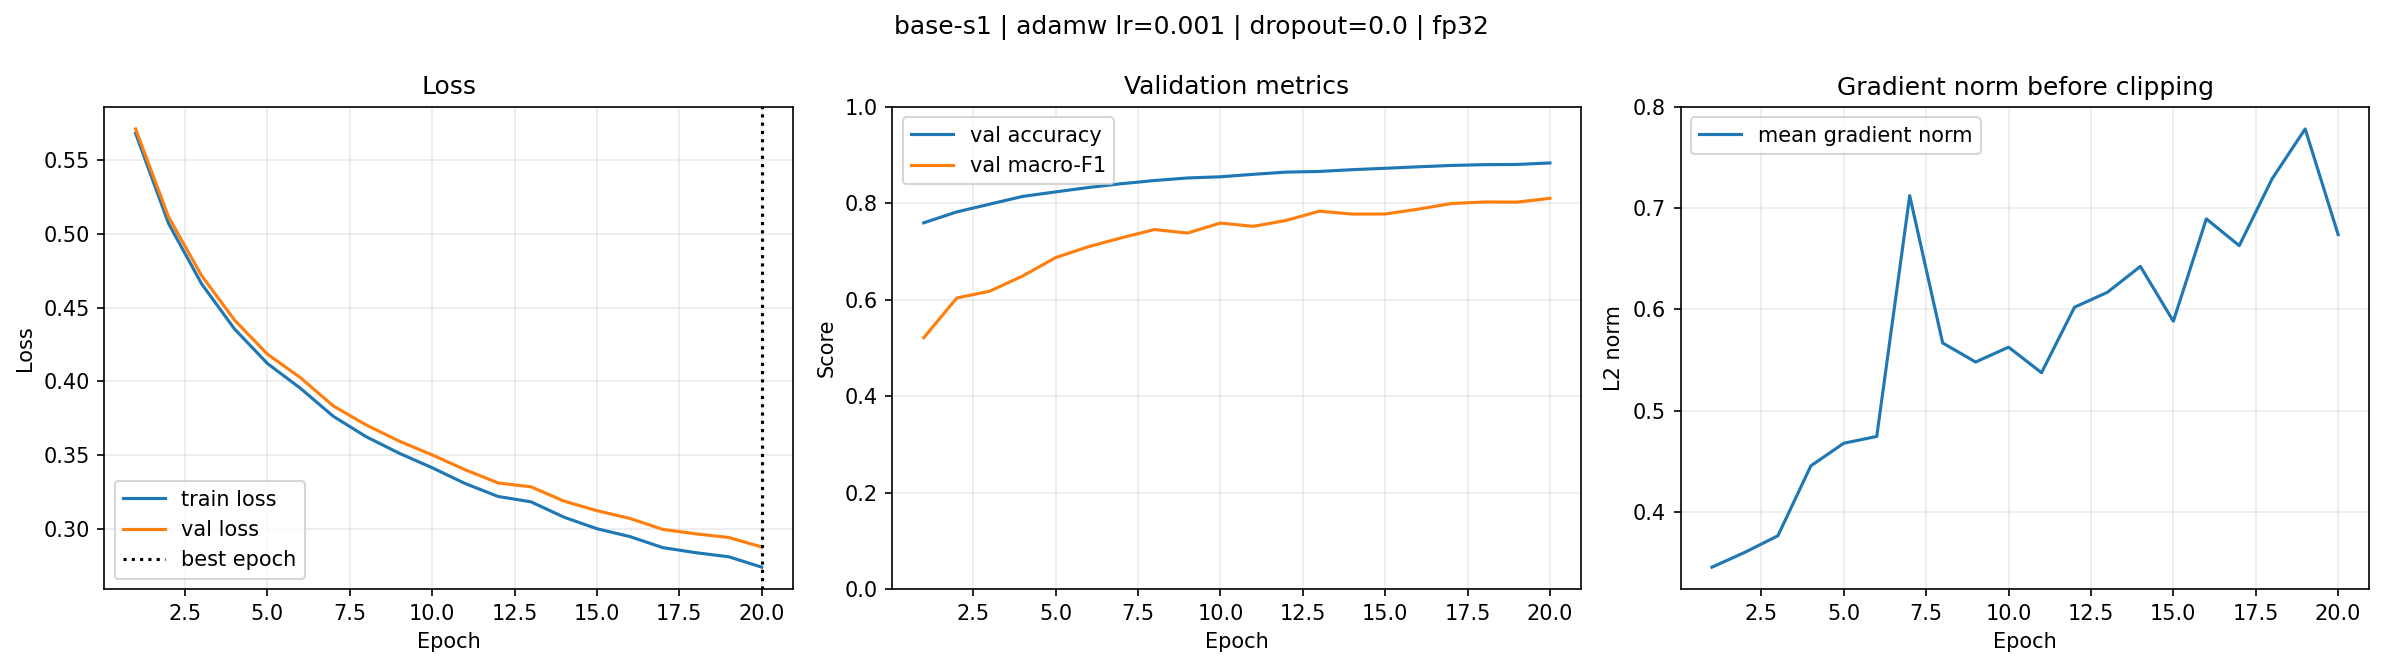

In [3]:
cfg = {'exp_id': 'base-s1', 'group': 'baseline', 'description': 'M-base, AdamW lr=1e-3, He', 'loss': 'ce', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.810539**, chênh lệch với base-s1 **+0.000000**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

{
  "step0_loss": 1.9781567018815485,
  "best_val_loss": 0.28757234388173225,
  "best_epoch": 20,
  "final_train_loss": 0.27382240572089506,
  "final_val_loss": 0.28757234388173225,
  "val_acc": 0.884587250704589,
  "val_macro_f1": 0.8128493532287756,
  "time_per_epoch_s": 0.42480549205001805,
  "peak_mem_MB": 161.318359375,
  "diverged": false
}


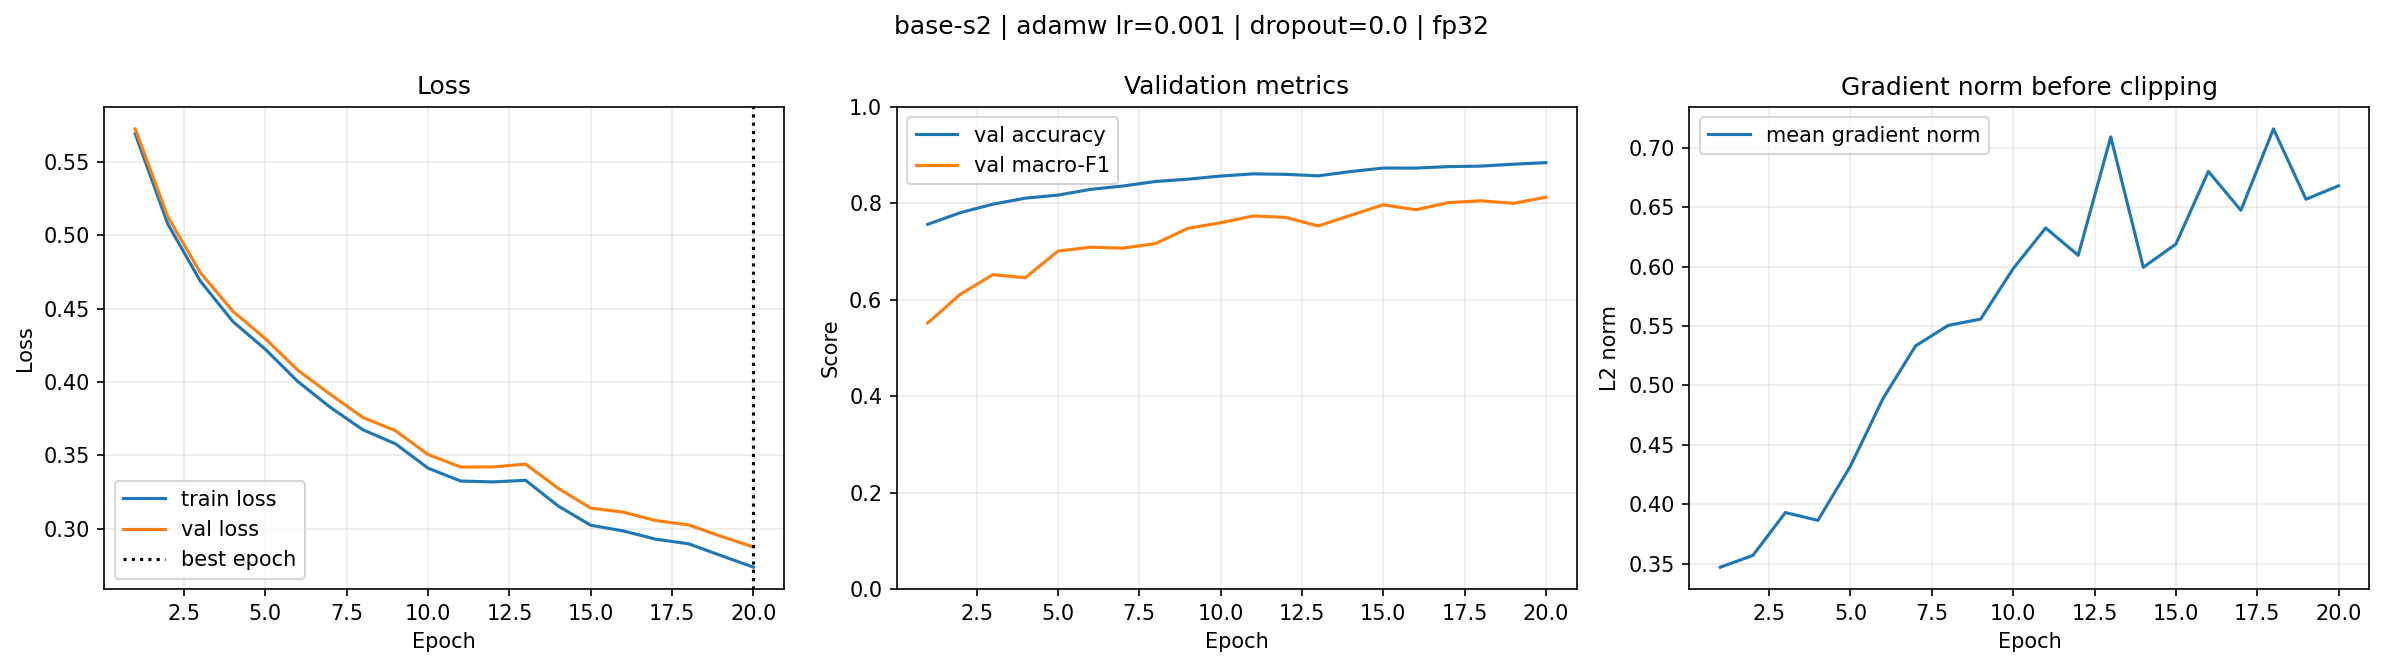

In [4]:
cfg = {'exp_id': 'base-s2', 'group': 'baseline', 'description': 'Baseline repeat, seed 2', 'loss': 'ce', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 2}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.812849**, chênh lệch với base-s1 **+0.002311**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

{
  "step0_loss": 1.9005399530688614,
  "best_val_loss": 0.2934093584084592,
  "best_epoch": 20,
  "final_train_loss": 0.27912410857783915,
  "final_val_loss": 0.2934093584084592,
  "val_acc": 0.8803489597900217,
  "val_macro_f1": 0.8083332183474771,
  "time_per_epoch_s": 0.3979958650000128,
  "peak_mem_MB": 161.50146484375,
  "diverged": false
}


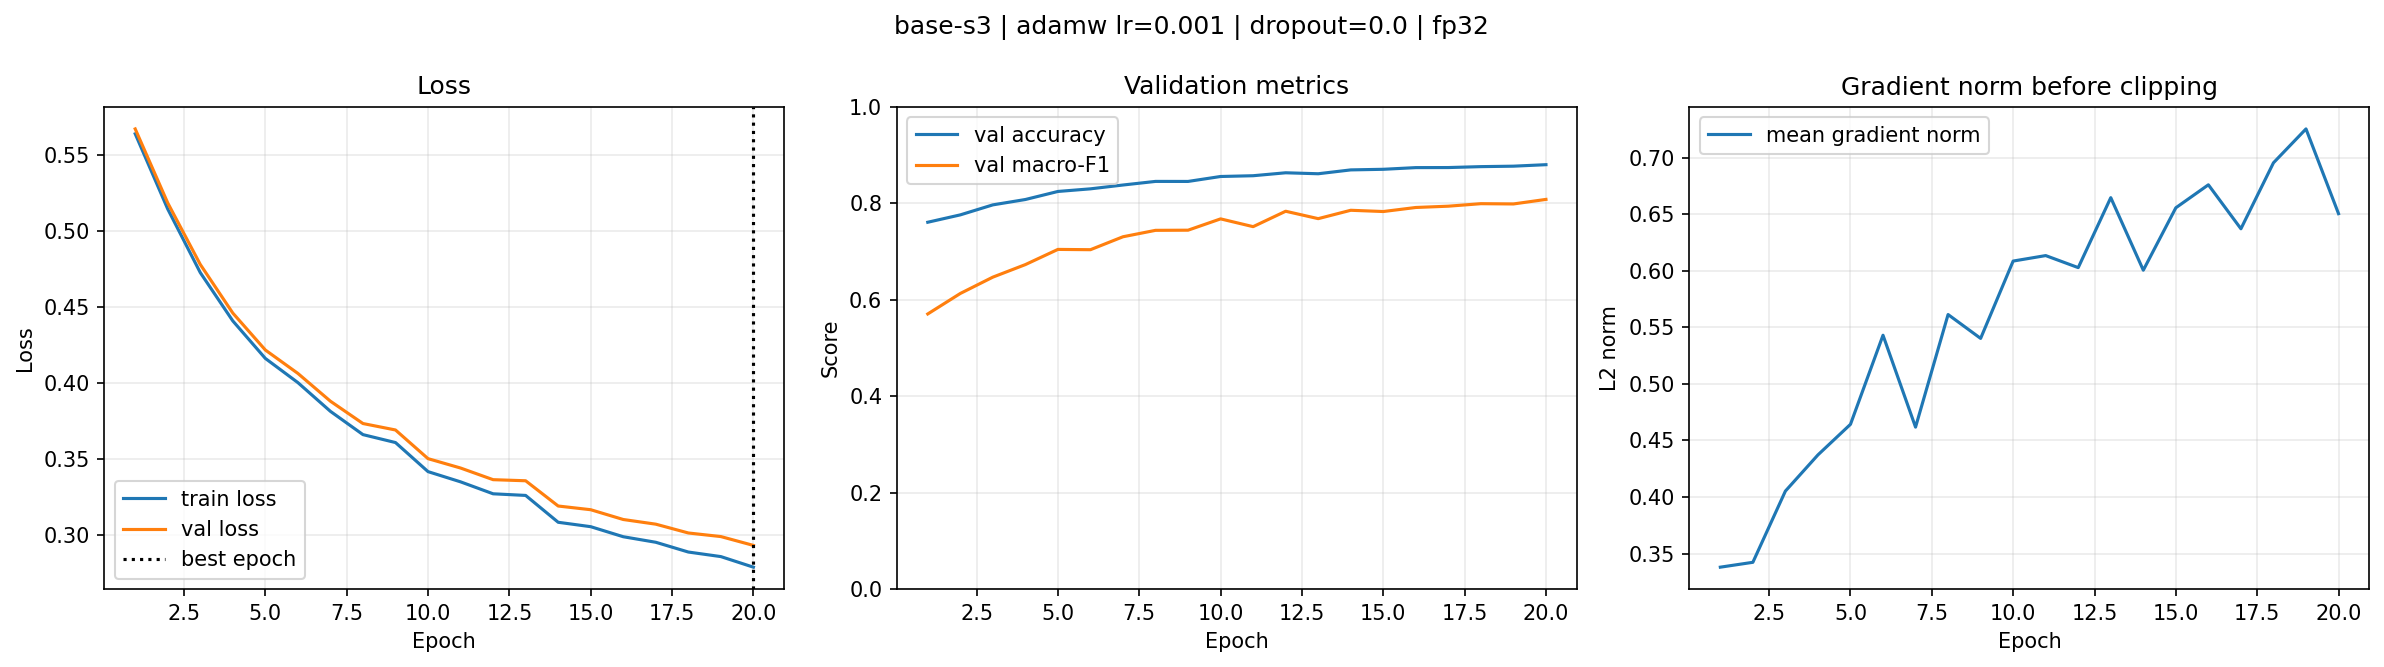

In [5]:
cfg = {'exp_id': 'base-s3', 'group': 'baseline', 'description': 'Baseline repeat, seed 3', 'loss': 'ce', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 3}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.808333**, chênh lệch với base-s1 **-0.002205**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

## Part 2 — Các chủ đề thí nghiệm

Giữ nguyên seed=1, split, số epoch và batch; mỗi thí nghiệm ghi đủ yếu tố thay đổi trong cfg. Adam và AdamW có weight_decay=0 nên tương đương trong thiết lập này.

### loss-mse

Giả thuyết lý thuyết: CE thường phù hợp hơn cho phân lớp; MSE ở đây dùng logits thô và one-hot, không so trực tiếp trị số loss với CE.

{
  "step0_loss": 0.6358503211013448,
  "best_val_loss": 0.02882067333352126,
  "best_epoch": 20,
  "final_train_loss": 0.027870035030578773,
  "final_val_loss": 0.02882067333352126,
  "val_acc": 0.8743465071749748,
  "val_macro_f1": 0.7590204129234761,
  "time_per_epoch_s": 0.4261545501999933,
  "peak_mem_MB": 161.71533203125,
  "diverged": false
}


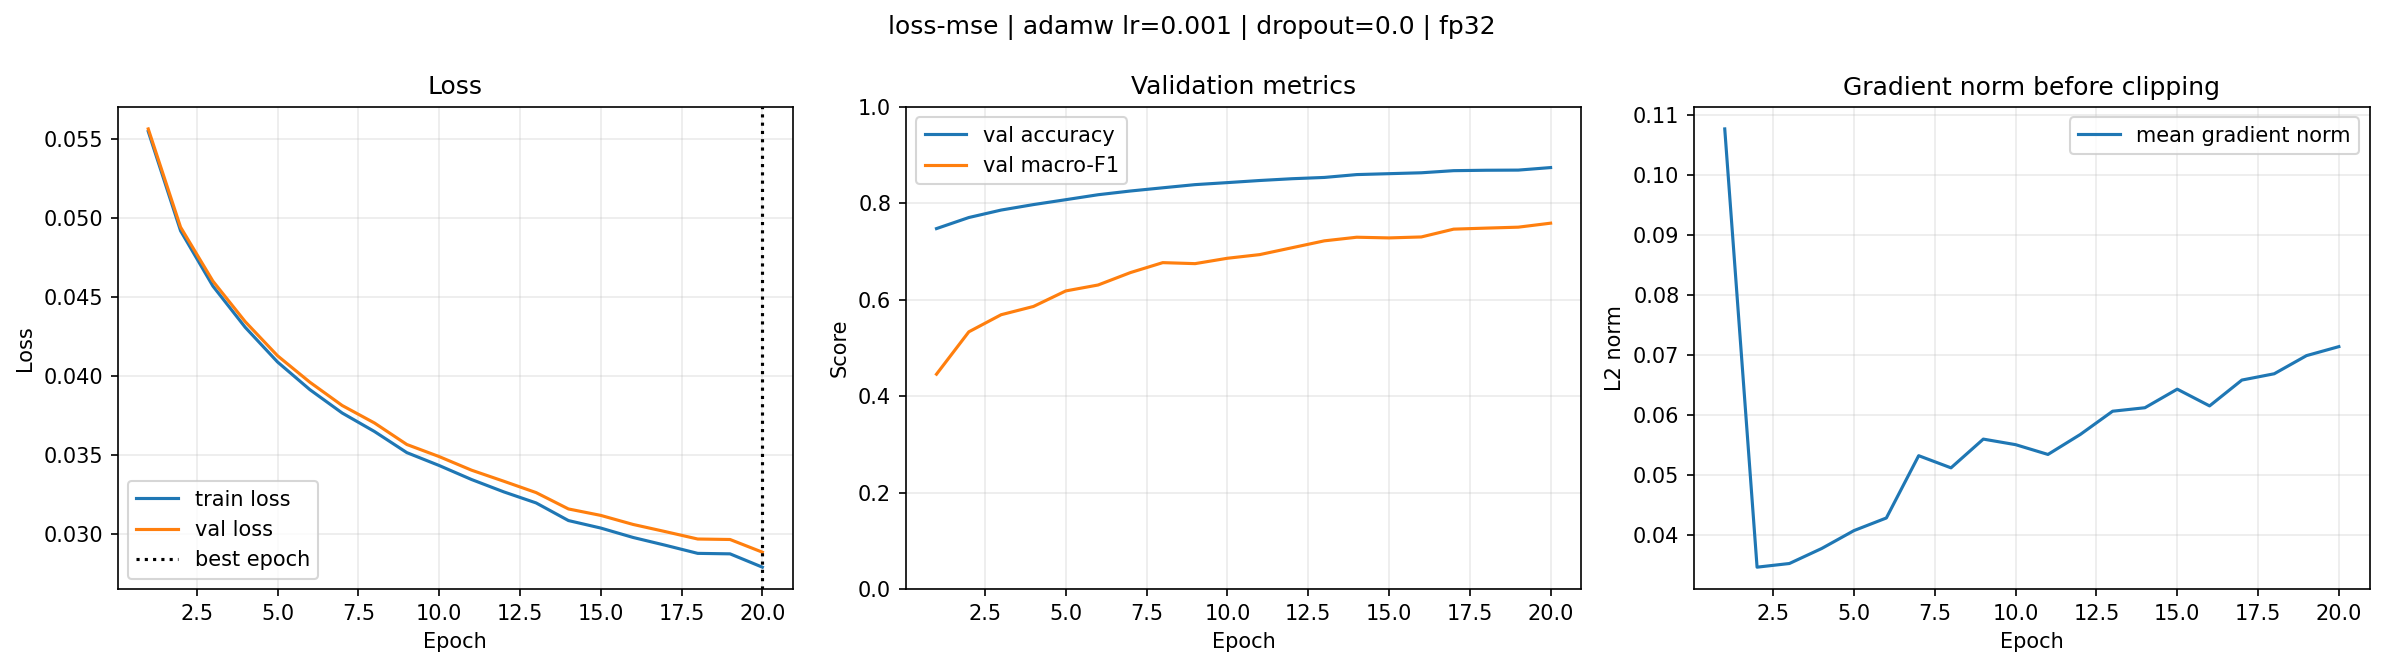

In [6]:
cfg = {'exp_id': 'loss-mse', 'group': 'loss', 'description': 'MSE on one-hot labels', 'loss': 'mse', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.759020**, chênh lệch với base-s1 **-0.051518**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### opt-sgdm-lr01

Giả thuyết lý thuyết: Momentum tích luỹ hướng gradient; Adam thích nghi bước theo từng tham số. Chỉnh lr trong lưới cho từng bộ tối ưu.

{
  "step0_loss": 2.269061788393712,
  "best_val_loss": 0.4384593225403088,
  "best_epoch": 20,
  "final_train_loss": 0.4320220136821856,
  "final_val_loss": 0.4384593225403088,
  "val_acc": 0.8159463006389708,
  "val_macro_f1": 0.6616020830040074,
  "time_per_epoch_s": 0.3874024855999892,
  "peak_mem_MB": 161.6845703125,
  "diverged": false
}


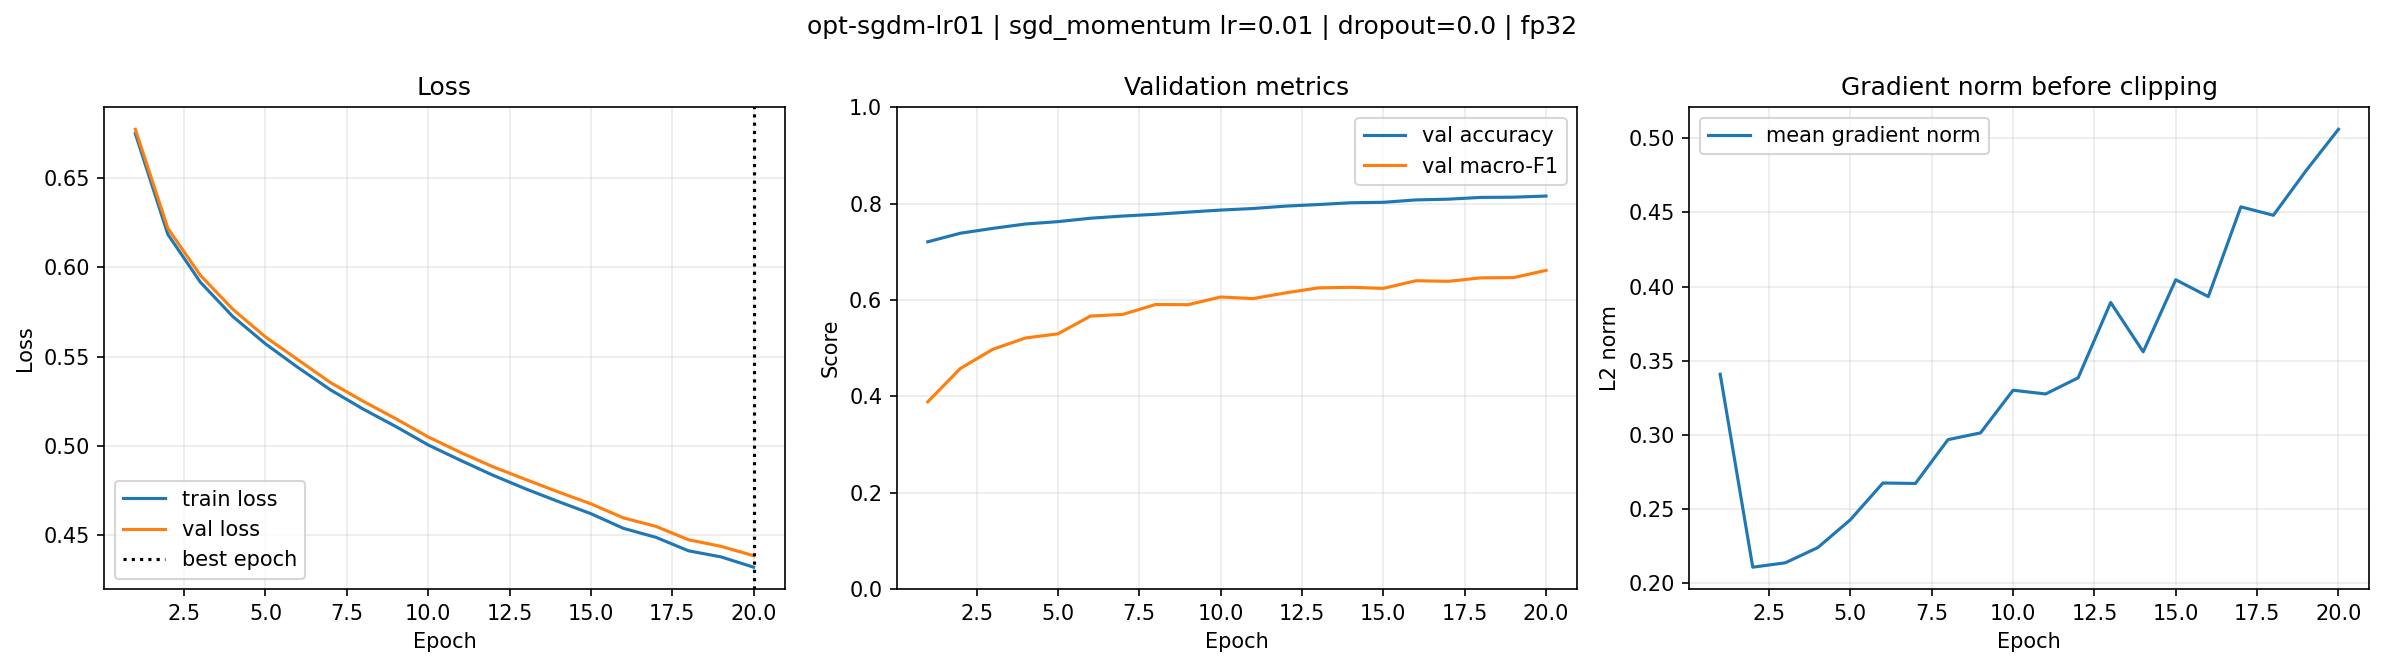

In [7]:
cfg = {'exp_id': 'opt-sgdm-lr01', 'group': 'optimizer', 'description': 'SGD momentum, lr=0.01', 'loss': 'ce', 'optimizer': 'sgd_momentum', 'lr': 0.01, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.661602**, chênh lệch với base-s1 **-0.148937**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### opt-sgdm-lr05

Giả thuyết lý thuyết: Momentum tích luỹ hướng gradient; Adam thích nghi bước theo từng tham số. Chỉnh lr trong lưới cho từng bộ tối ưu.

{
  "step0_loss": 2.269061788393712,
  "best_val_loss": 0.31713171496233006,
  "best_epoch": 19,
  "final_train_loss": 0.320164991355389,
  "final_val_loss": 0.3321563509947277,
  "val_acc": 0.8697424754200641,
  "val_macro_f1": 0.766244743482292,
  "time_per_epoch_s": 0.37057138850001936,
  "peak_mem_MB": 161.86767578125,
  "diverged": false
}


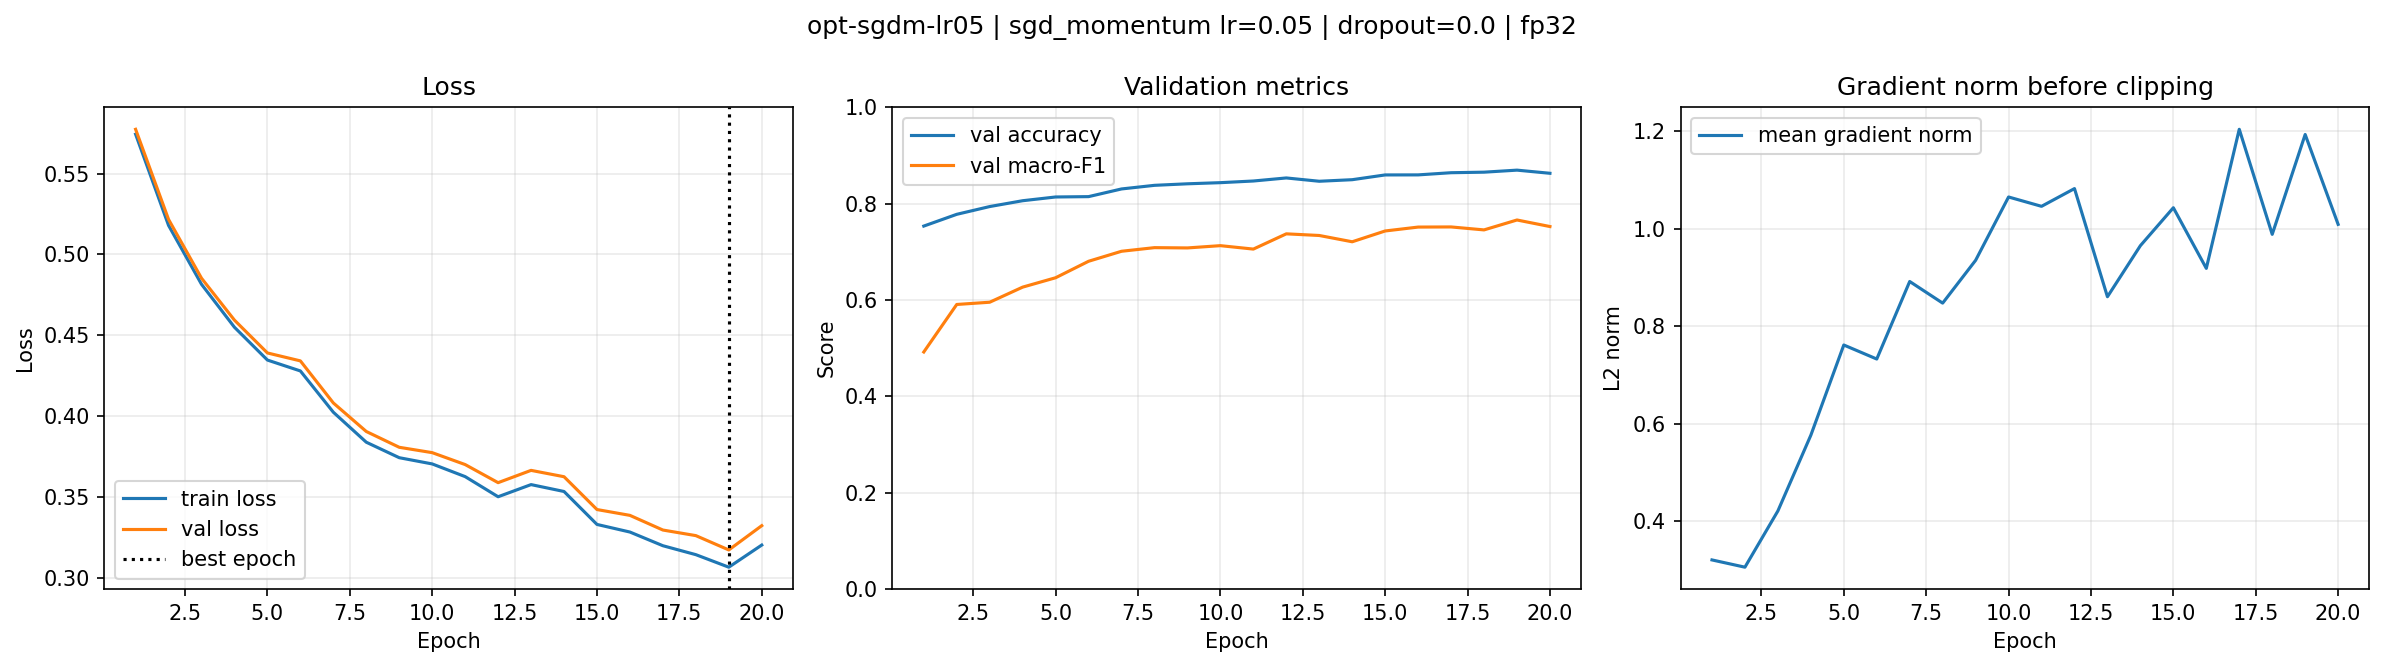

In [8]:
cfg = {'exp_id': 'opt-sgdm-lr05', 'group': 'optimizer', 'description': 'SGD momentum, lr=0.05', 'loss': 'ce', 'optimizer': 'sgd_momentum', 'lr': 0.05, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.766245**, chênh lệch với base-s1 **-0.044294**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### opt-adam-lr3e4

Giả thuyết lý thuyết: Momentum tích luỹ hướng gradient; Adam thích nghi bước theo từng tham số. Chỉnh lr trong lưới cho từng bộ tối ưu.

{
  "step0_loss": 2.269061788393712,
  "best_val_loss": 0.3774216148970816,
  "best_epoch": 20,
  "final_train_loss": 0.36878903307288935,
  "final_val_loss": 0.3774216148970816,
  "val_acc": 0.8458402357952712,
  "val_macro_f1": 0.7347919884872669,
  "time_per_epoch_s": 0.40994468189999794,
  "peak_mem_MB": 162.23388671875,
  "diverged": false
}


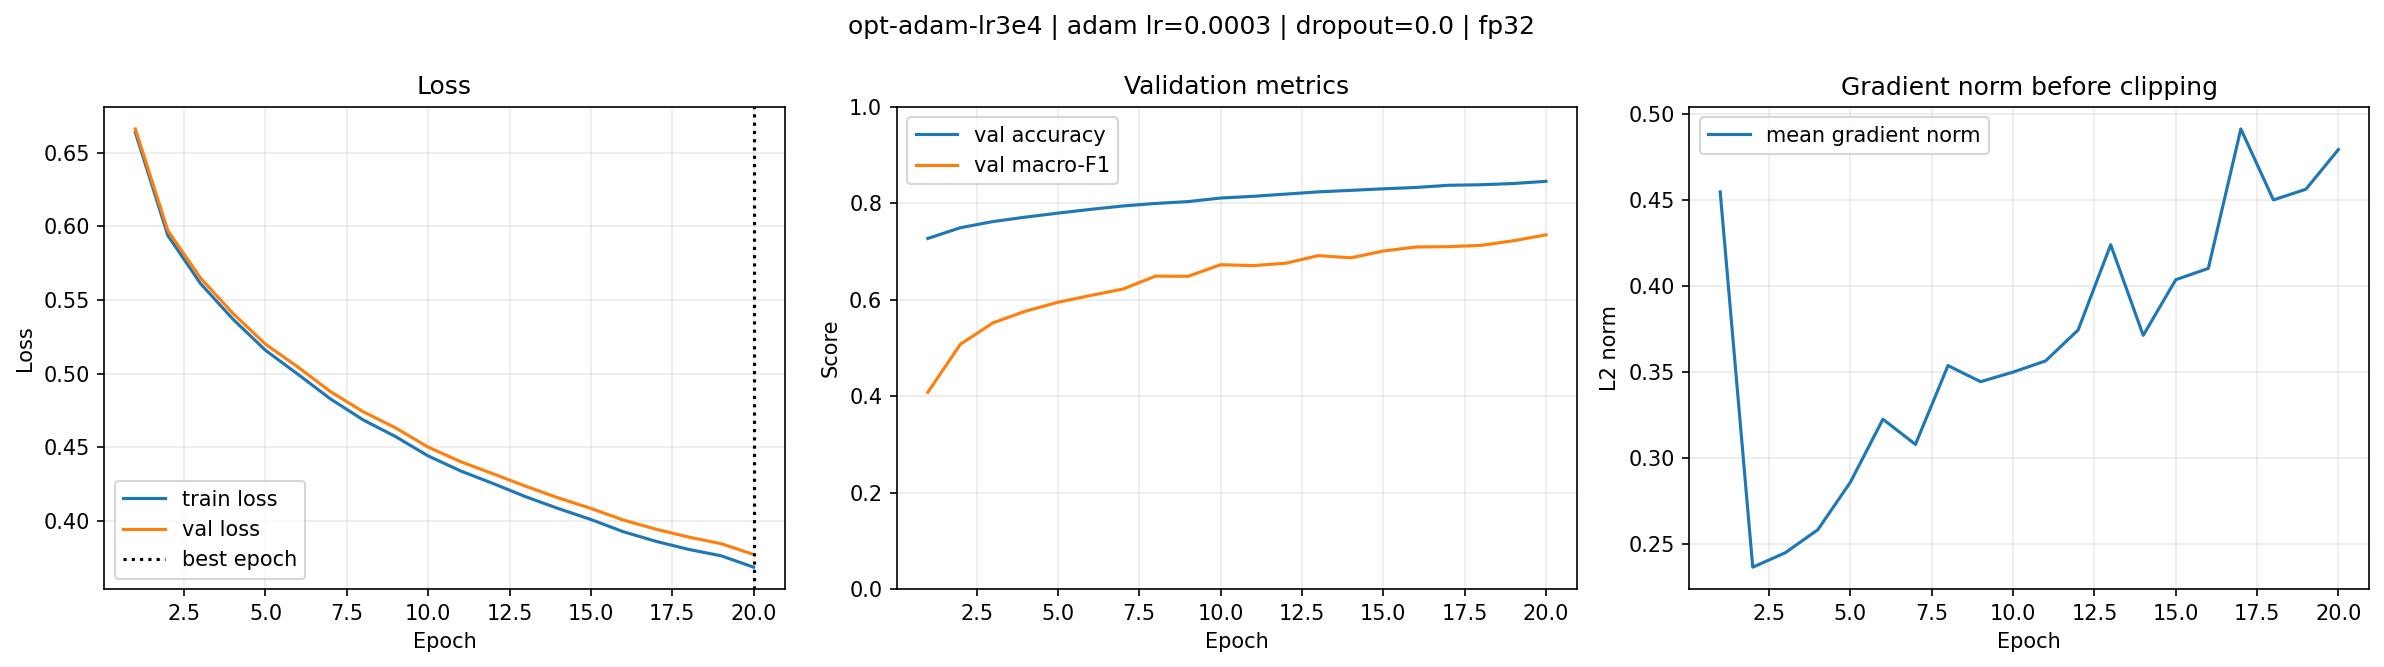

In [9]:
cfg = {'exp_id': 'opt-adam-lr3e4', 'group': 'optimizer', 'description': 'Adam, lr=3e-4', 'loss': 'ce', 'optimizer': 'adam', 'lr': 0.0003, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.734792**, chênh lệch với base-s1 **-0.075747**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### opt-adam-lr1e3

Giả thuyết lý thuyết: Momentum tích luỹ hướng gradient; Adam thích nghi bước theo từng tham số. Chỉnh lr trong lưới cho từng bộ tối ưu.

{
  "step0_loss": 2.269061788393712,
  "best_val_loss": 0.28759079256888903,
  "best_epoch": 20,
  "final_train_loss": 0.2739207979441141,
  "final_val_loss": 0.28759079256888903,
  "val_acc": 0.8839310686086788,
  "val_macro_f1": 0.8105385838093785,
  "time_per_epoch_s": 0.4230451794000146,
  "peak_mem_MB": 162.4169921875,
  "diverged": false
}


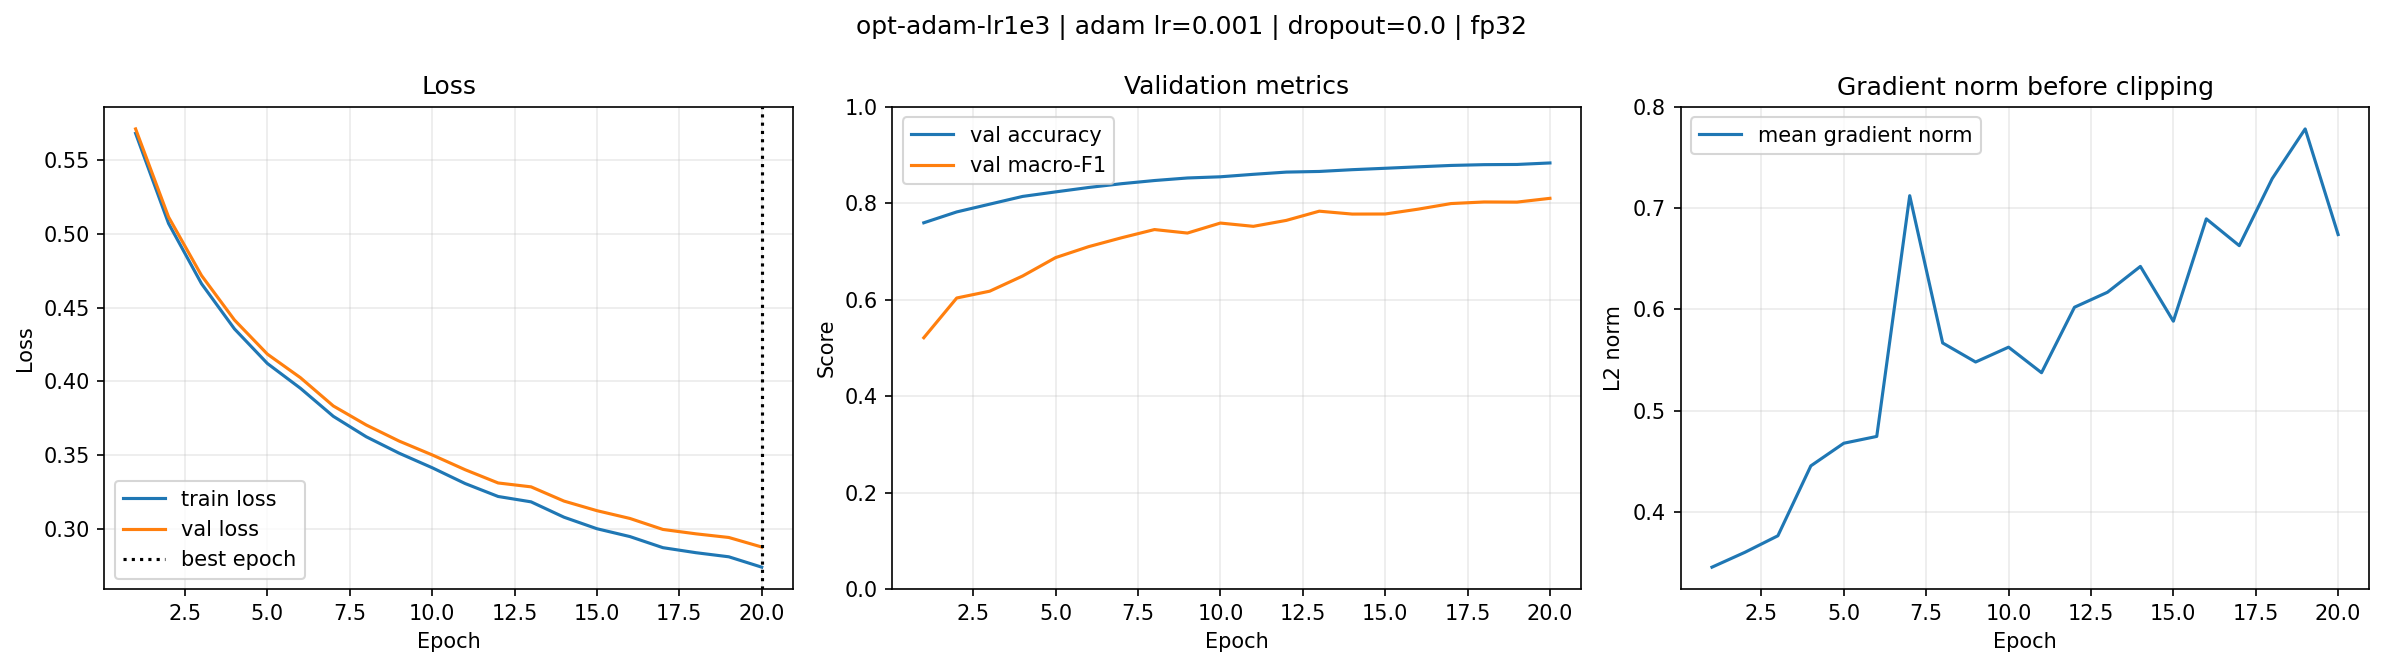

In [10]:
cfg = {'exp_id': 'opt-adam-lr1e3', 'group': 'optimizer', 'description': 'Adam, lr=1e-3', 'loss': 'ce', 'optimizer': 'adam', 'lr': 0.001, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.810539**, chênh lệch với base-s1 **+0.000000**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### lr-adamw-3e4

Giả thuyết lý thuyết: lr nhỏ hơn có thể chậm trong cùng ngân sách epoch; lr cao có thể tăng dao động.

{
  "step0_loss": 2.269061788393712,
  "best_val_loss": 0.3774216148970816,
  "best_epoch": 20,
  "final_train_loss": 0.36878903307288935,
  "final_val_loss": 0.3774216148970816,
  "val_acc": 0.8458402357952712,
  "val_macro_f1": 0.7347919884872669,
  "time_per_epoch_s": 0.41708170434999375,
  "peak_mem_MB": 162.60009765625,
  "diverged": false
}


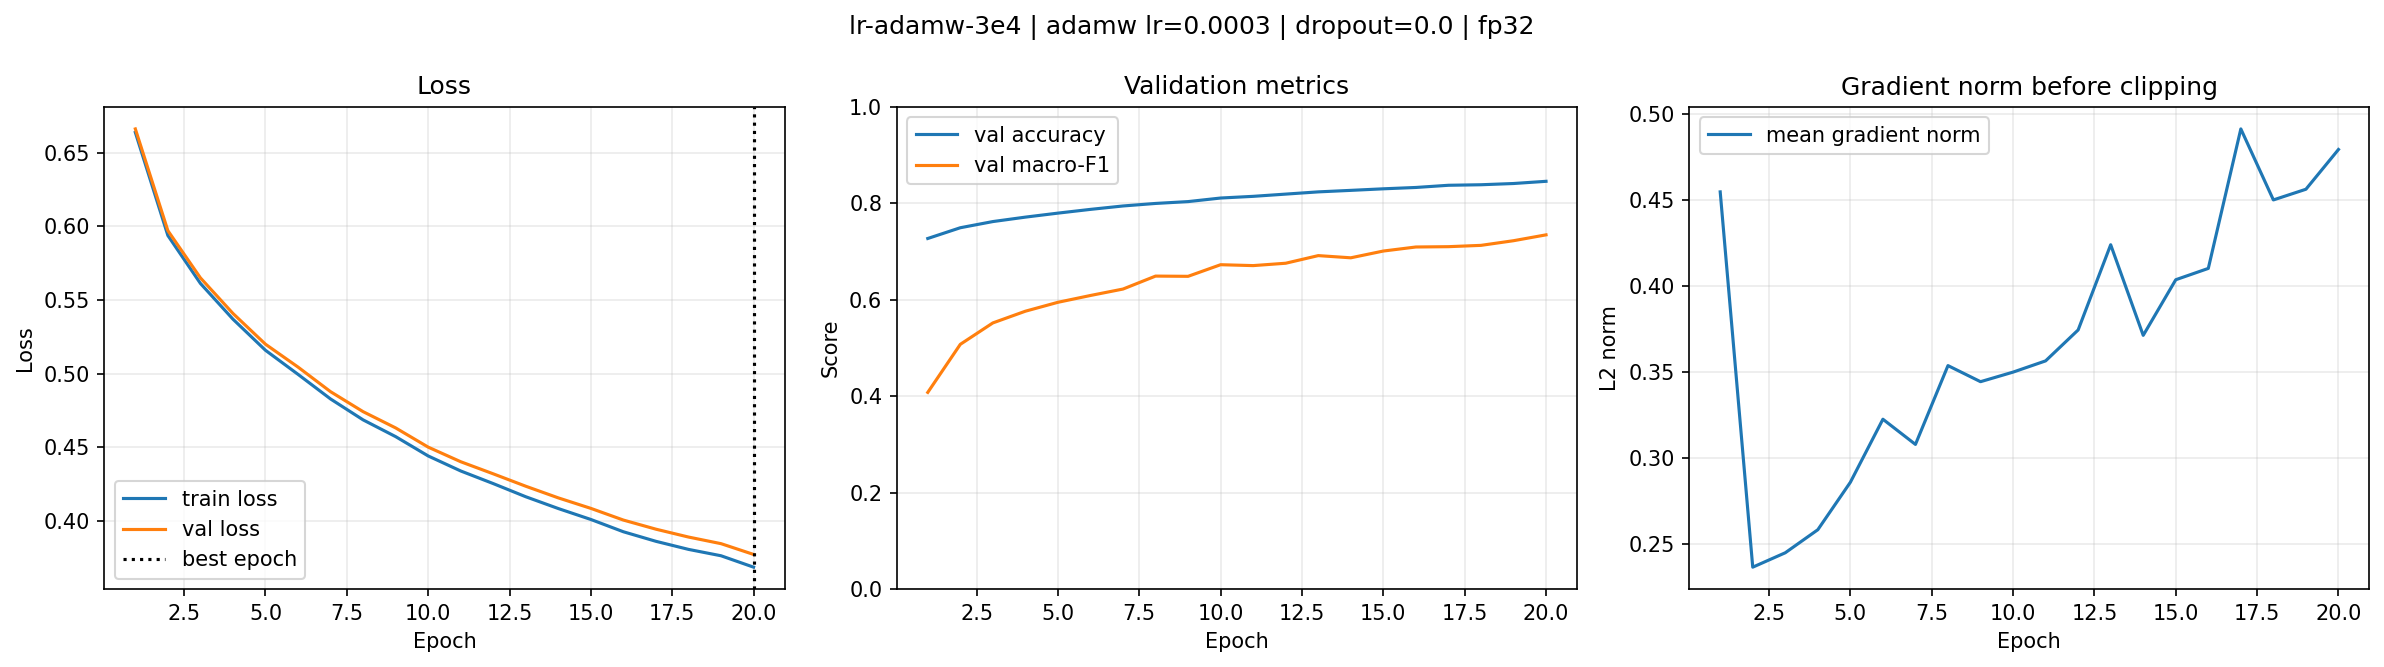

In [11]:
cfg = {'exp_id': 'lr-adamw-3e4', 'group': 'hyperparameter', 'description': 'AdamW, lower learning rate', 'loss': 'ce', 'optimizer': 'adamw', 'lr': 0.0003, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.734792**, chênh lệch với base-s1 **-0.075747**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### dropout-p03

Giả thuyết lý thuyết: Dropout giảm overfit nhưng có thể làm chậm học nếu baseline chưa quá khớp mạnh.

{
  "step0_loss": 2.269061788393712,
  "best_val_loss": 0.3649630790420414,
  "best_epoch": 20,
  "final_train_loss": 0.36012841610280066,
  "final_val_loss": 0.3649630790420414,
  "val_acc": 0.8495944579505604,
  "val_macro_f1": 0.7495524199248325,
  "time_per_epoch_s": 0.4236440889999983,
  "peak_mem_MB": 162.783203125,
  "diverged": false
}


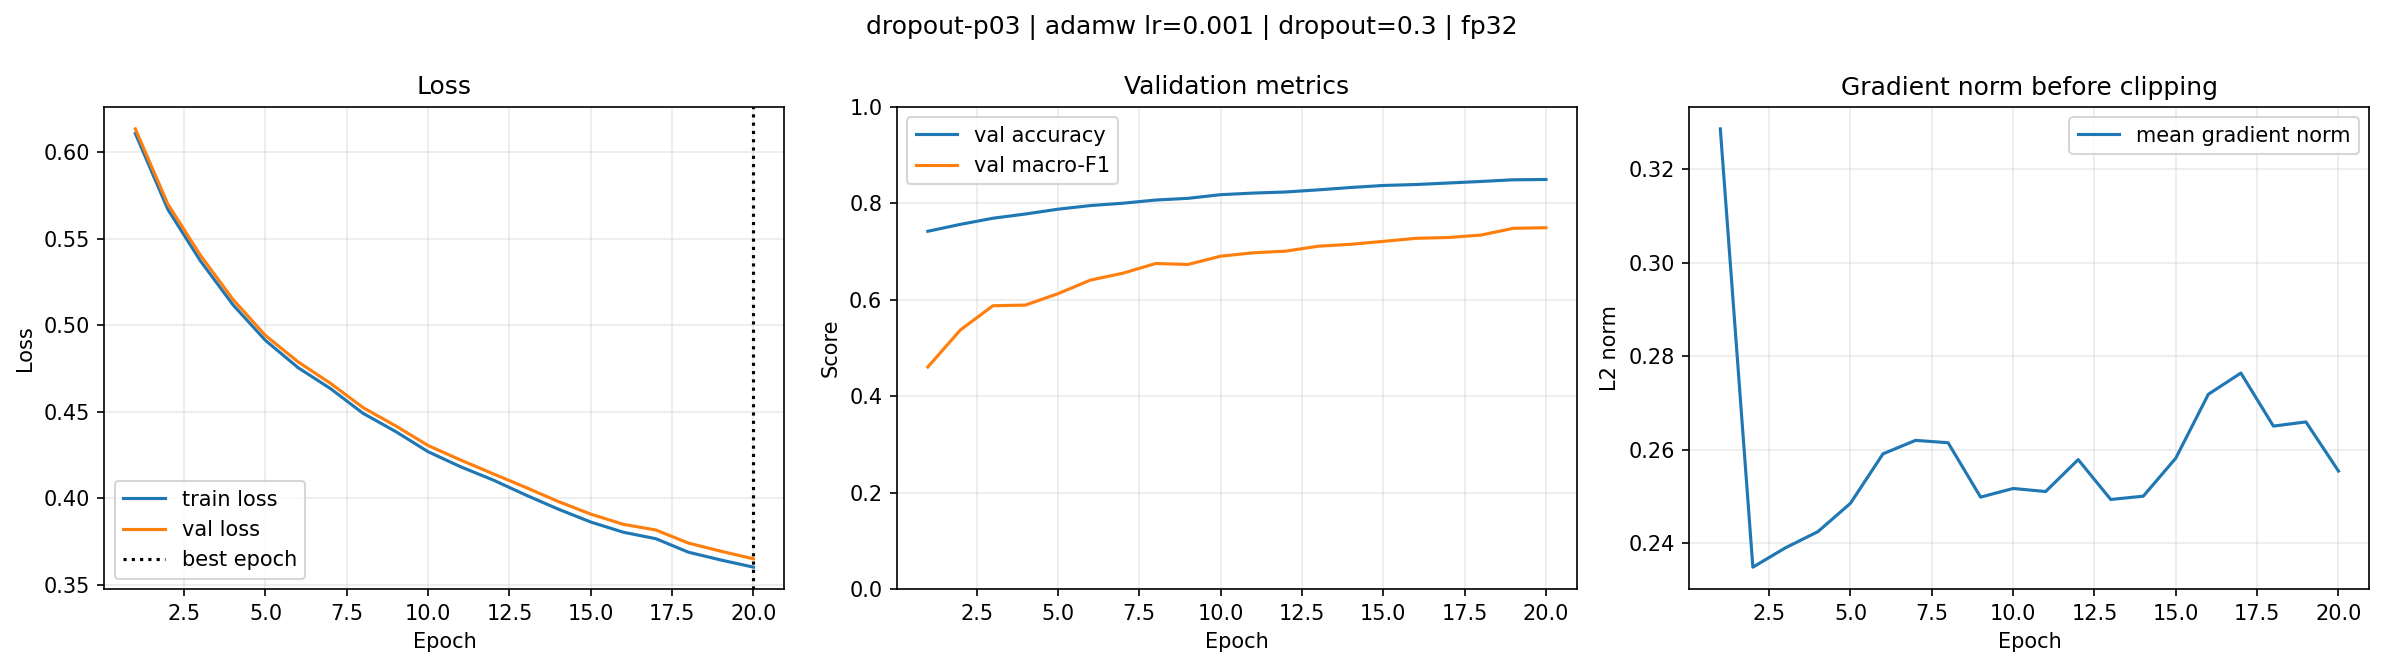

In [12]:
cfg = {'exp_id': 'dropout-p03', 'group': 'dropout', 'description': 'Dropout p=0.3', 'loss': 'ce', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.3, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.749552**, chênh lệch với base-s1 **-0.060986**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### clip-highlr-none

Giả thuyết lý thuyết: Clipping giới hạn bước lớn. Kiểm tra grad_norm trước clip và đường loss; không mặc định lr cao sẽ phân kỳ.

{
  "step0_loss": 2.269061788393712,
  "best_val_loss": 0.22970013195705974,
  "best_epoch": 20,
  "final_train_loss": 0.20561194014061898,
  "final_val_loss": 0.22970013195705974,
  "val_acc": 0.9073922678083518,
  "val_macro_f1": 0.8676104419728523,
  "time_per_epoch_s": 0.42157225770000084,
  "peak_mem_MB": 162.96630859375,
  "diverged": false
}


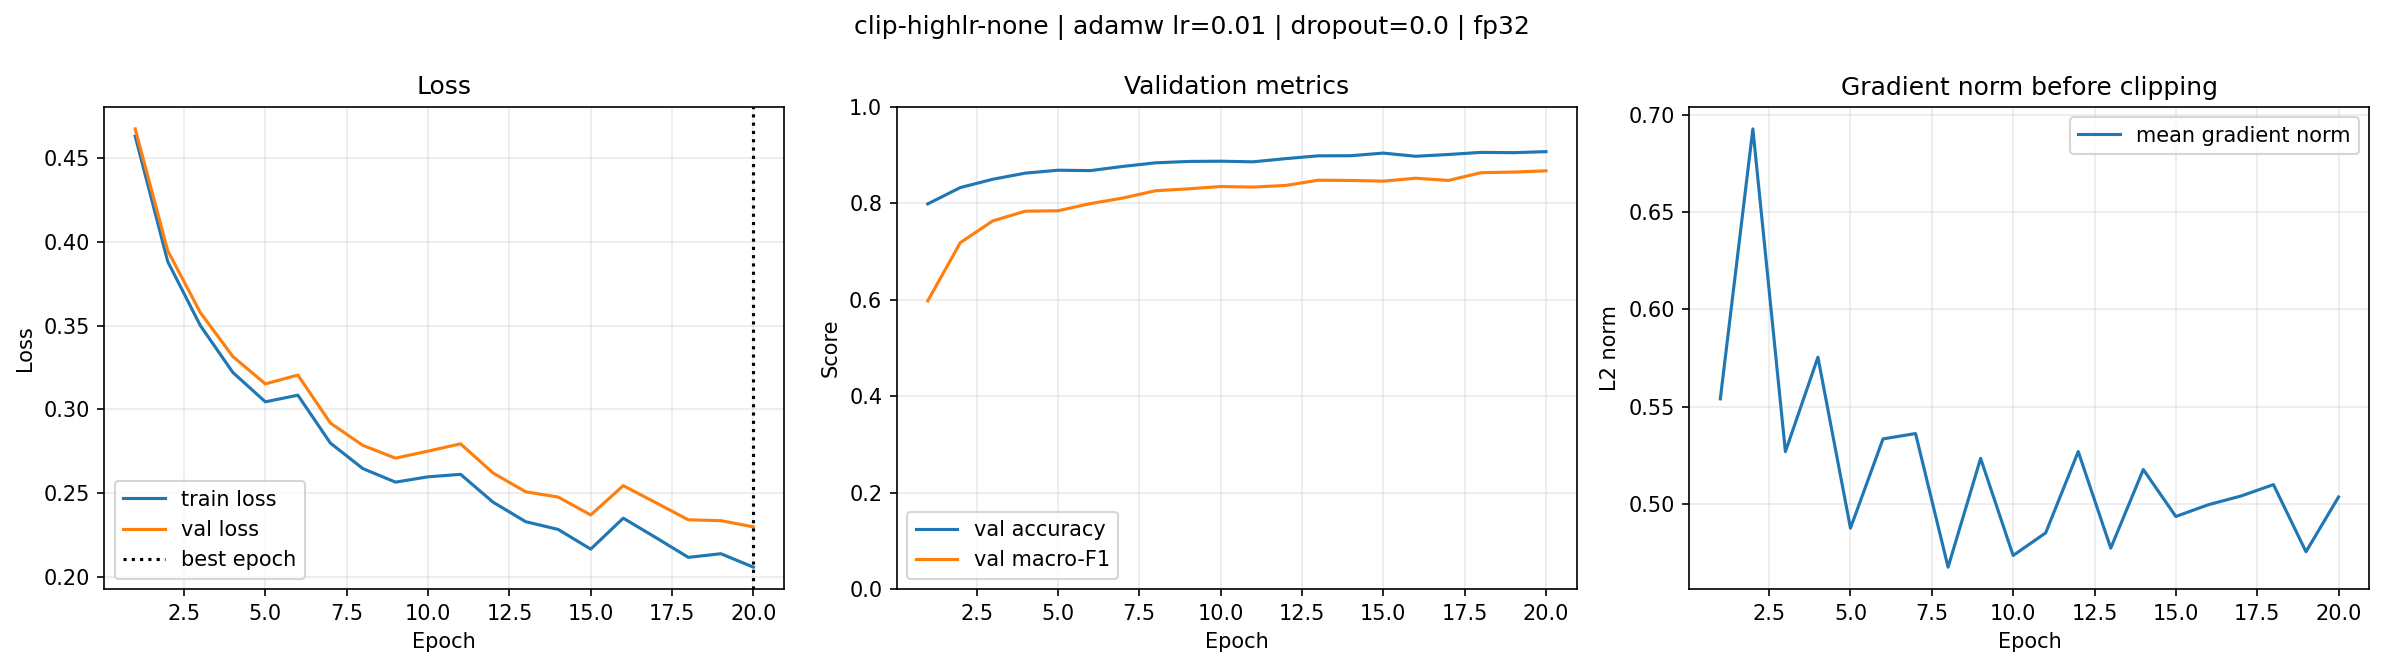

In [13]:
cfg = {'exp_id': 'clip-highlr-none', 'group': 'clipping', 'description': 'AdamW lr=0.01, no clipping', 'loss': 'ce', 'optimizer': 'adamw', 'lr': 0.01, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.867610**, chênh lệch với base-s1 **+0.057072**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### clip-highlr-1

Giả thuyết lý thuyết: Clipping giới hạn bước lớn. Kiểm tra grad_norm trước clip và đường loss; không mặc định lr cao sẽ phân kỳ.

{
  "step0_loss": 2.269061788393712,
  "best_val_loss": 0.22296222218886314,
  "best_epoch": 19,
  "final_train_loss": 0.20229581040040914,
  "final_val_loss": 0.22578901159294254,
  "val_acc": 0.9107592349562187,
  "val_macro_f1": 0.8671875241333343,
  "time_per_epoch_s": 0.438121021850003,
  "peak_mem_MB": 163.1494140625,
  "diverged": false
}


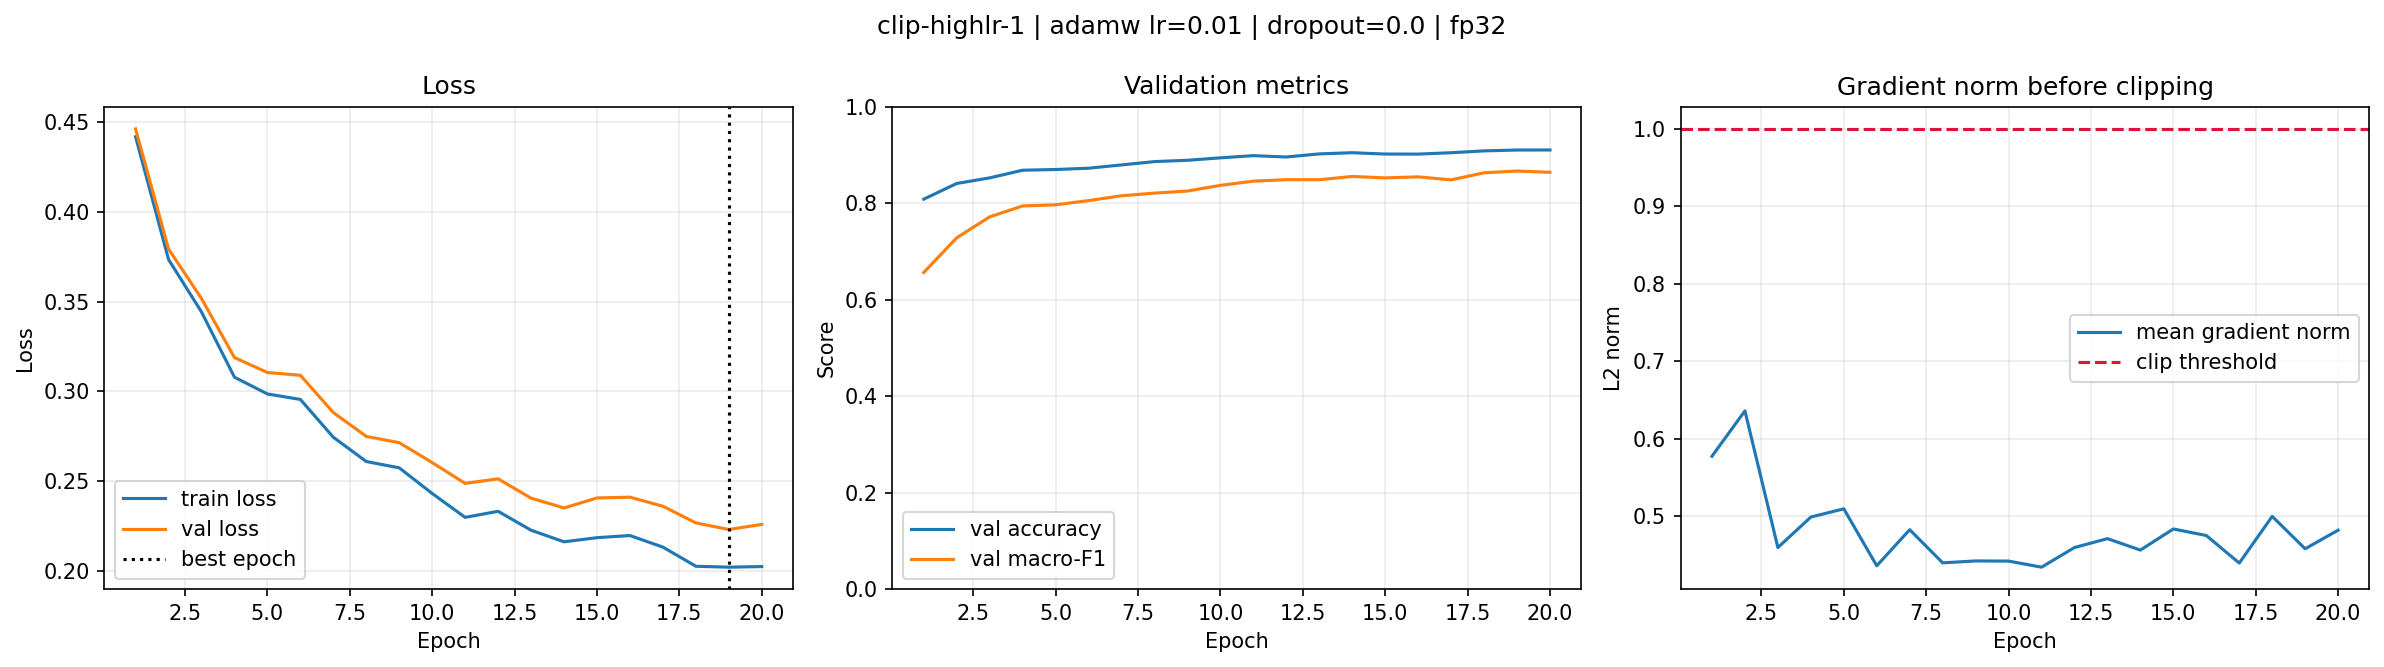

In [14]:
cfg = {'exp_id': 'clip-highlr-1', 'group': 'clipping', 'description': 'AdamW lr=0.01, clip norm 1', 'loss': 'ce', 'optimizer': 'adamw', 'lr': 0.01, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': 1.0, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.867188**, chênh lệch với base-s1 **+0.056649**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### precision-bf16

Giả thuyết lý thuyết: Precision thấp có thể giảm bộ nhớ/tăng tốc; MLP nhỏ và đánh giá FP32 có thể làm overhead chiếm ưu thế. T4 không có BF16 native.

{
  "step0_loss": 2.269061788393712,
  "best_val_loss": 0.28832162162866276,
  "best_epoch": 20,
  "final_train_loss": 0.2759269311369999,
  "final_val_loss": 0.28832162162866276,
  "val_acc": 0.8846948215399841,
  "val_macro_f1": 0.8121172525672452,
  "time_per_epoch_s": 0.47164686669998446,
  "peak_mem_MB": 163.33251953125,
  "diverged": false
}


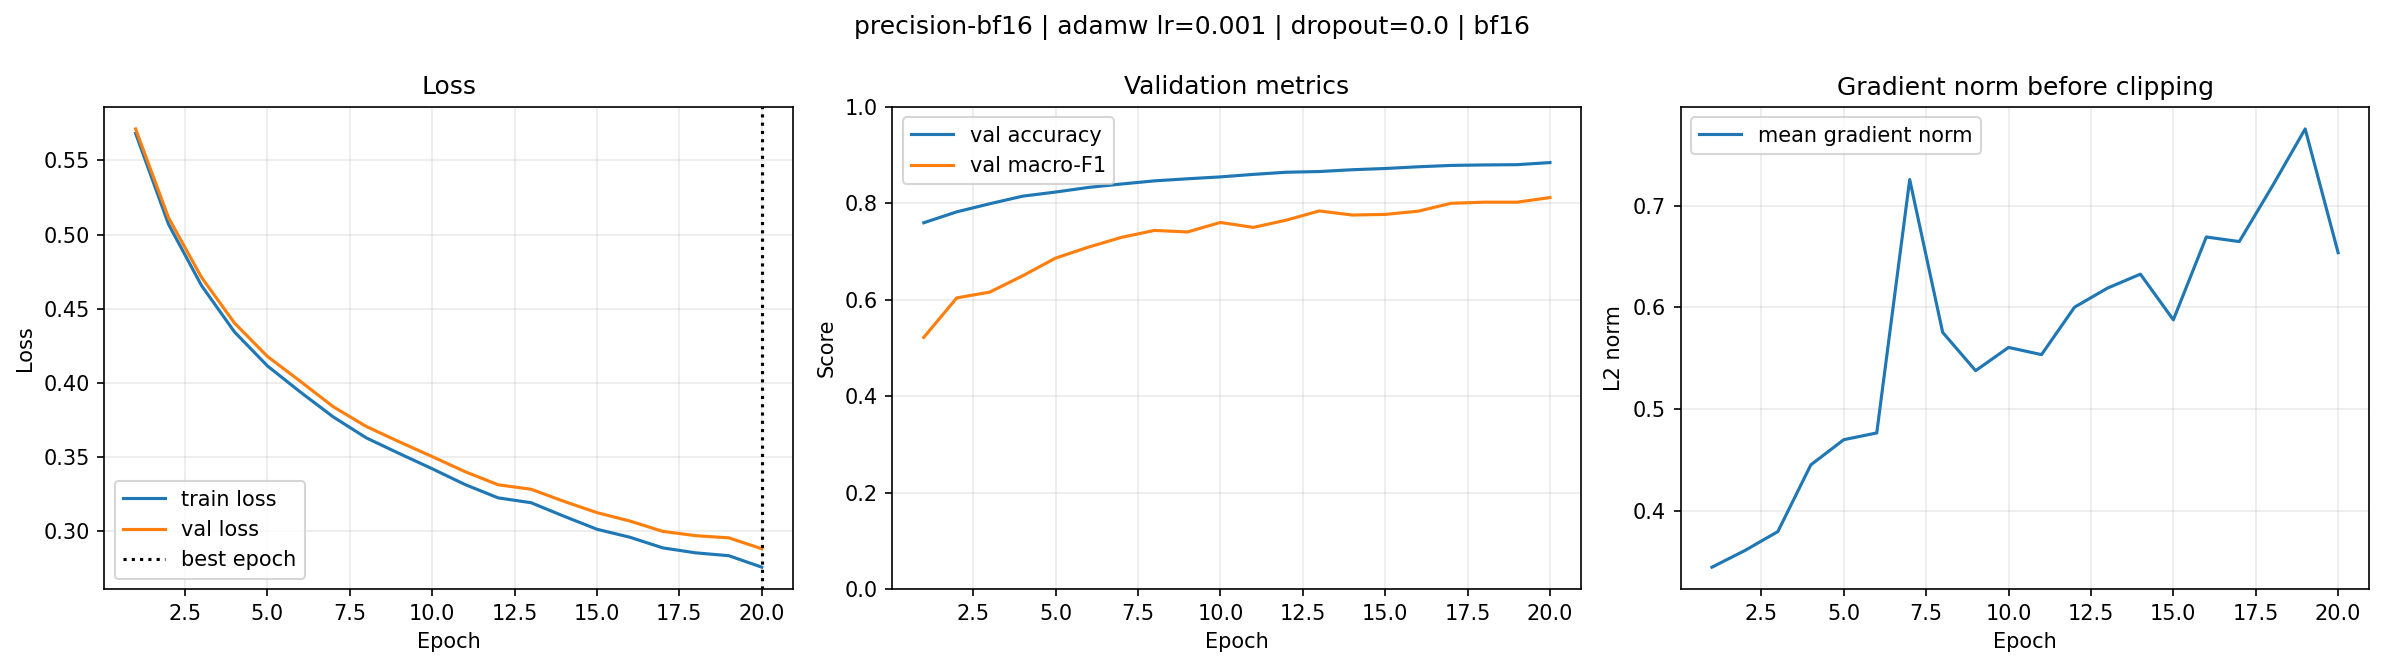

In [15]:
cfg = {'exp_id': 'precision-bf16', 'group': 'mixed_precision', 'description': 'BF16 requested; CPU falls back to FP32', 'loss': 'ce', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'bf16', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.812117**, chênh lệch với base-s1 **+0.001579**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### precision-fp16

Giả thuyết lý thuyết: Precision thấp có thể giảm bộ nhớ/tăng tốc; MLP nhỏ và đánh giá FP32 có thể làm overhead chiếm ưu thế. T4 không có BF16 native.

{
  "step0_loss": 2.269061788393712,
  "best_val_loss": 0.2875404350523853,
  "best_epoch": 20,
  "final_train_loss": 0.27409289828408506,
  "final_val_loss": 0.2875404350523853,
  "val_acc": 0.884544222370431,
  "val_macro_f1": 0.8127790715003889,
  "time_per_epoch_s": 0.5496686643500027,
  "peak_mem_MB": 163.5166015625,
  "diverged": false
}


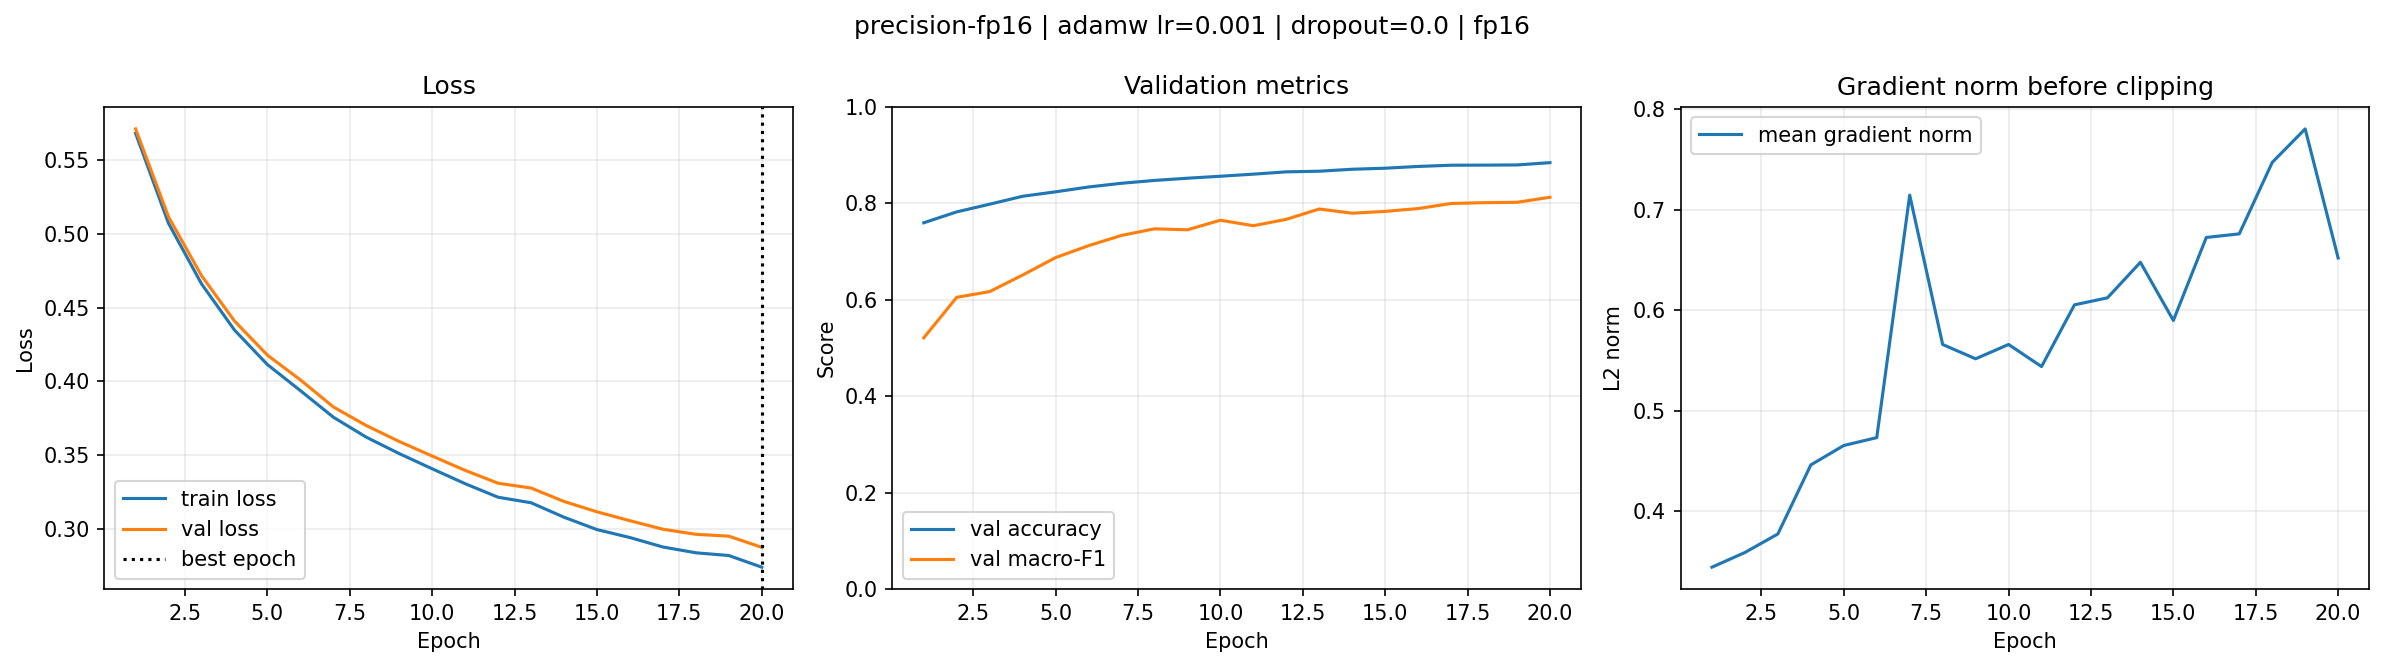

In [16]:
cfg = {'exp_id': 'precision-fp16', 'group': 'mixed_precision', 'description': 'FP16 mixed precision on Tesla T4', 'loss': 'ce', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'he', 'clip_norm': None, 'precision': 'fp16', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.812779**, chênh lệch với base-s1 **+0.002240**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### init-xavier

Giả thuyết lý thuyết: He thích hợp ReLU; Xavier/normal nhỏ có thể giảm phương sai qua lớp. Zeros không phá đối xứng.

{
  "step0_loss": 2.0221761899351347,
  "best_val_loss": 0.3003156890183035,
  "best_epoch": 20,
  "final_train_loss": 0.28853345708057093,
  "final_val_loss": 0.3003156890183035,
  "val_acc": 0.8782835997504357,
  "val_macro_f1": 0.8038252517683885,
  "time_per_epoch_s": 0.411226255899993,
  "peak_mem_MB": 163.69873046875,
  "diverged": false
}


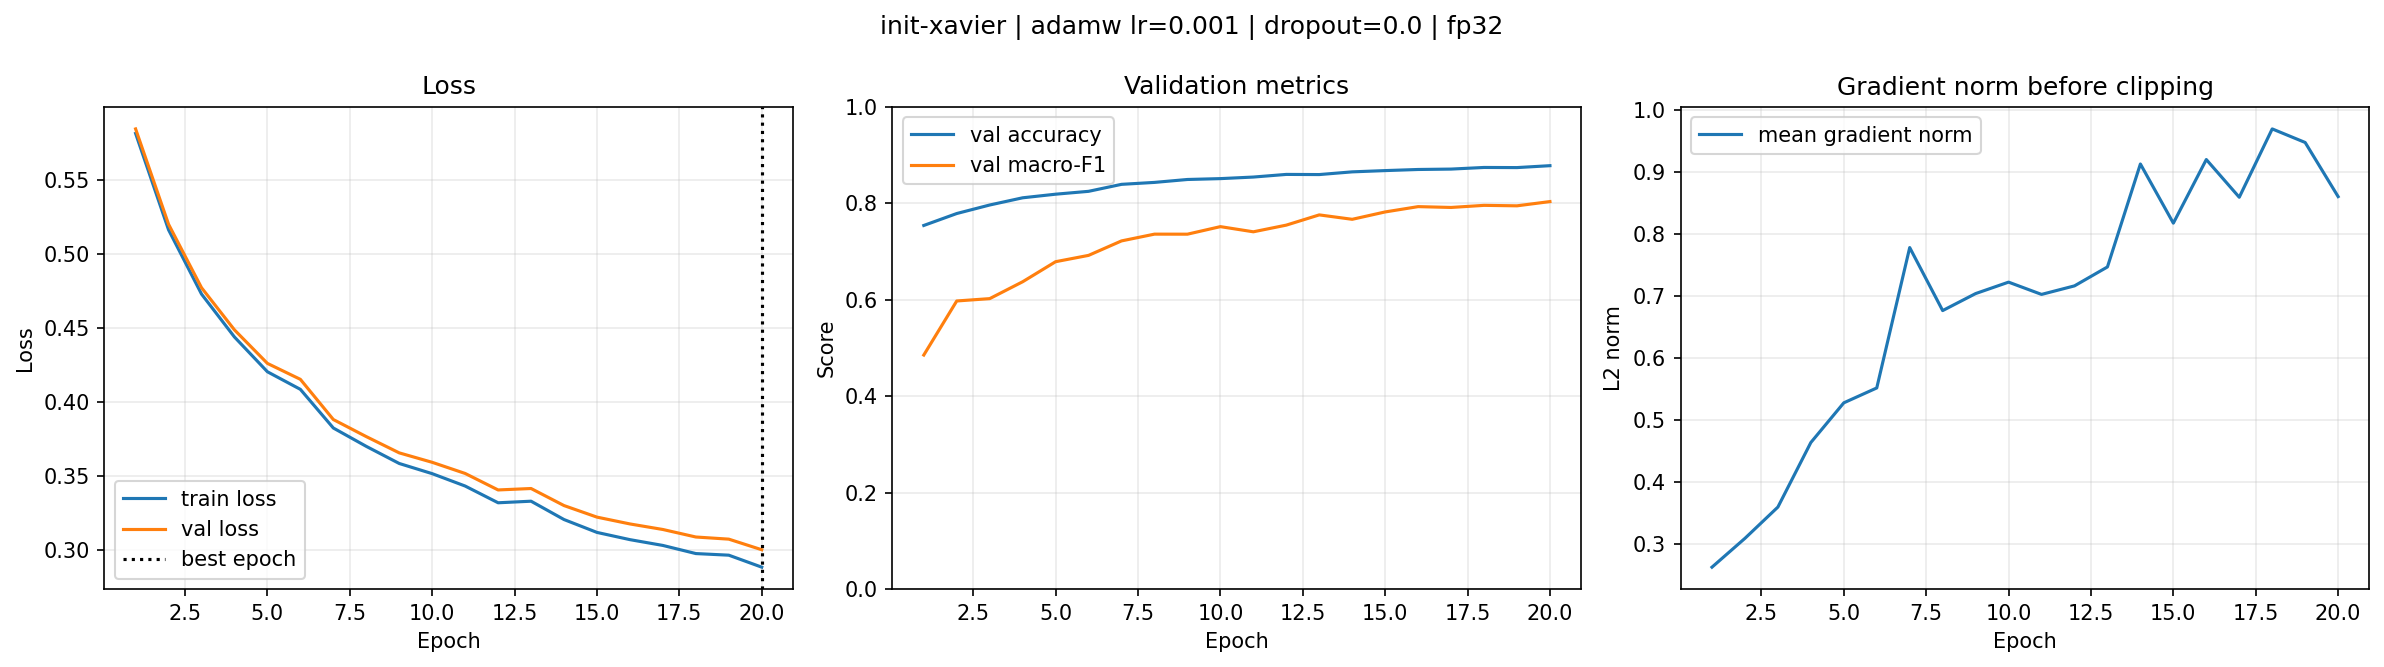

In [17]:
cfg = {'exp_id': 'init-xavier', 'group': 'initialization', 'description': 'Xavier normal initialization', 'loss': 'ce', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'xavier', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.803825**, chênh lệch với base-s1 **-0.006713**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

### init-normal

Giả thuyết lý thuyết: He thích hợp ReLU; Xavier/normal nhỏ có thể giảm phương sai qua lớp. Zeros không phá đối xứng.

{
  "step0_loss": 1.945995658844474,
  "best_val_loss": 0.3738819723969875,
  "best_epoch": 20,
  "final_train_loss": 0.36623027784802115,
  "final_val_loss": 0.3738819723969875,
  "val_acc": 0.8457003937092575,
  "val_macro_f1": 0.7561769579452472,
  "time_per_epoch_s": 0.42809804295001186,
  "peak_mem_MB": 163.8818359375,
  "diverged": false
}


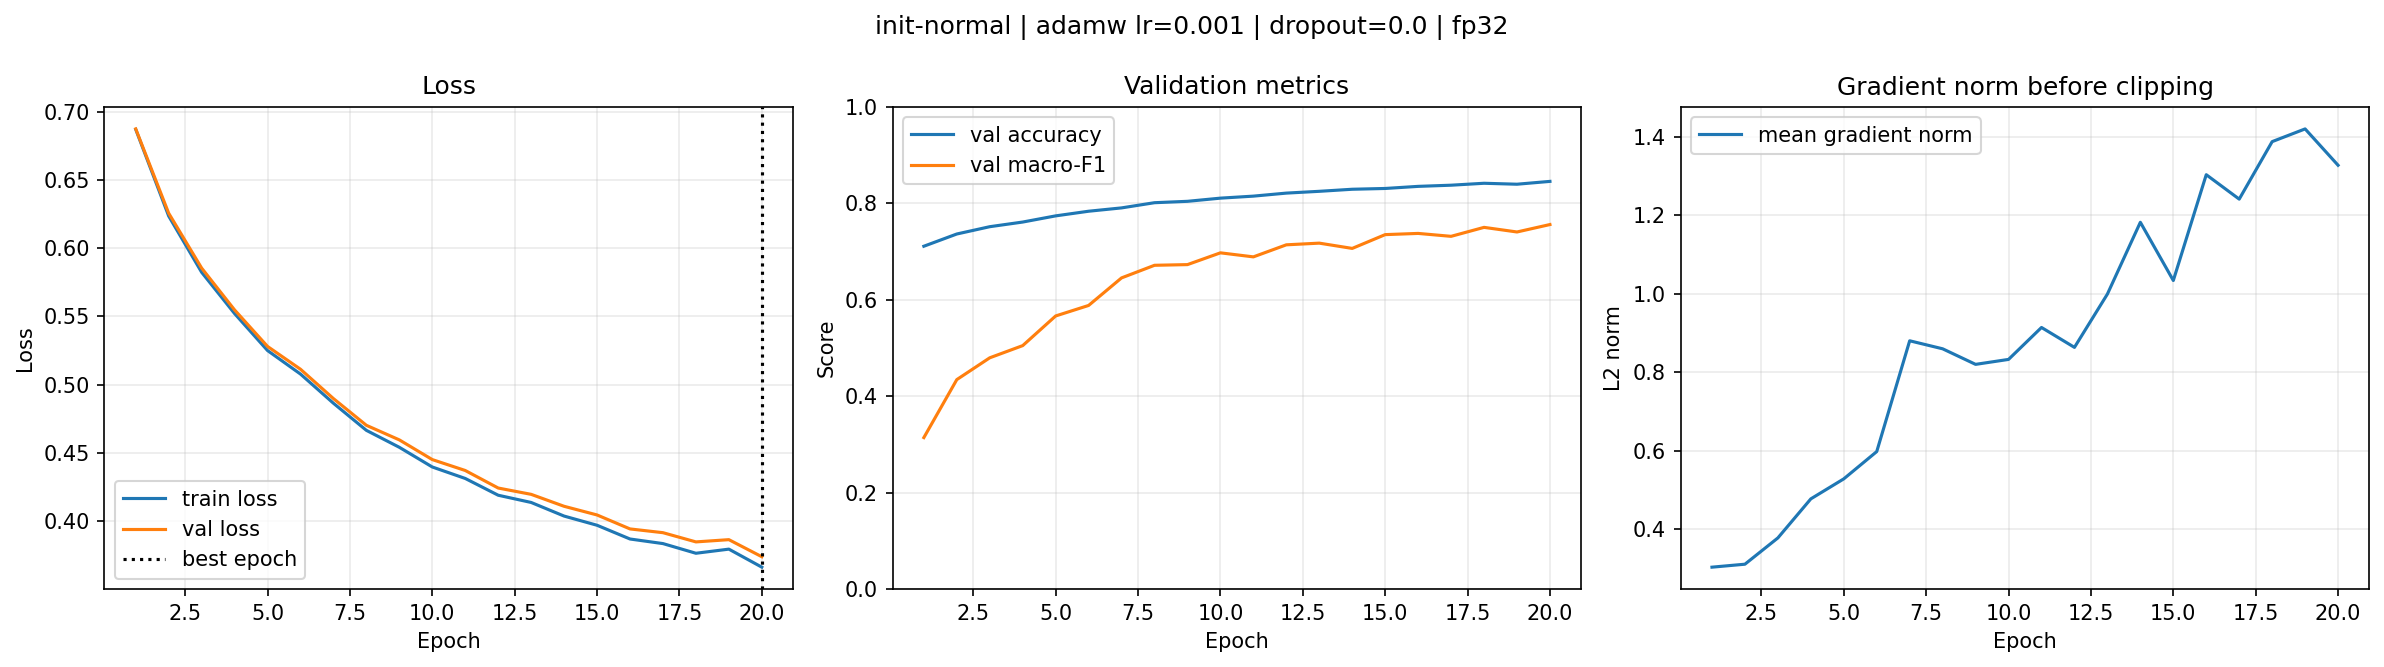

In [18]:
cfg = {'exp_id': 'init-normal', 'group': 'initialization', 'description': 'Normal N(0, 0.01) initialization', 'loss': 'ce', 'optimizer': 'adamw', 'lr': 0.001, 'weight_decay': 0.0, 'momentum': 0.9, 'batch': 2048, 'epochs': 20, 'hidden': [256, 128], 'dropout': 0.0, 'init': 'normal', 'clip_norm': None, 'precision': 'fp32', 'seed': 1}
completed.append(execute(cfg))

Nhận xét từ lượt Colab: macro-F1 val **0.756177**, chênh lệch với base-s1 **-0.054362**. Xem đường loss và grad norm ở ảnh. Một seed cho cấu hình này chưa đủ để khẳng định ý nghĩa thống kê.

## Part 3 — Chọn cấu hình và đánh giá cuối

Chọn macro-F1 validation cao nhất trước khi mở eval. Hàm dưới lặp baseline và cấu hình đã chọn cùng seed để khôi phục checkpoint; ghi lại các lượt lặp và chỉ chạy evaluate.py cho hai cấu hình. Các file eval JSON giữ nguyên đầu ra script chấm.

In [19]:
import finish_colab
finish_colab.main(str(out.relative_to(repo)))
selection = json.loads((out/'selection.json').read_text())
print(json.dumps(selection, indent=2))
print((out/'health_checks.json').read_text())


Selected by validation: clip-highlr-none


train=371,847; val=92,962; eval=116,203; majority-val accuracy=0.4876


FINAL_EVAL_COMPLETE {"base-s1": {"n_eval": 116203, "accuracy": 0.8835572231353752, "macro_f1": 0.8118771210239729, "per_class": [{"cls": 0, "support": 42368, "precision": 0.8938634106160815, "recall": 0.870845921450151, "f1": 0.882204554964433}, {"cls": 1, "support": 56661, "precision": 0.8853440526467545, "recall": 0.9212509486242741, "f1": 0.9029406677045493}, {"cls": 2, "support": 7151, "precision": 0.8575411207136883, "recall": 0.8602992588449168, "f1": 0.8589179755671902}, {"cls": 3, "support": 549, "precision": 0.7925636007827789, "recall": 0.7377049180327869, "f1": 0.7641509433962264}, {"cls": 4, "support": 1899, "precision": 0.8142857142857143, "recall": 0.5402843601895735, "f1": 0.6495726495726496}, {"cls": 5, "support": 3473, "precision": 0.7707458831126897, "recall": 0.6873020443420674, "f1": 0.7266362252663623}, {"cls": 6, "support": 4102, "precision": 0.9189808917197452, "recall": 0.879327157484154, "f1": 0.8987168306963996}], "confusion_matrix": [[36896, 5125, 4, 0, 42, 1

{
  "selected_exp_id": "clip-highlr-none",
  "criterion": "highest validation macro-F1 before eval",
  "eval_scores": {
    "base-s1": {
      "n_eval": 116203,
      "accuracy": 0.8835572231353752,
      "macro_f1": 0.8118771210239729,
      "per_class": [
        {
          "cls": 0,
          "support": 42368,
          "precision": 0.8938634106160815,
          "recall": 0.870845921450151,
          "f1": 0.882204554964433
        },
        {
          "cls": 1,
          "support": 56661,
          "precision": 0.8853440526467545,
          "recall": 0.9212509486242741,
          "f1": 0.9029406677045493
        },
        {
          "cls": 2,
          "support": 7151,
          "precision": 0.8575411207136883,
          "recall": 0.8602992588449168,
          "f1": 0.8589179755671902
        },
        {
          "cls": 3,
          "support": 549,
          "precision": 0.7925636007827789,
          "recall": 0.7377049180327869,
          "f1": 0.7641509433962264
        },

## Part 4 — Báo cáo và kiểm tra bài nộp

Đọc REPORT.md: số liệu theo exp_id, cơ chế, noise, phân tích lỗi từng lớp, trả lời câu hỏi và hạn chế. Họ tên và MSSV đã điền trong báo cáo và tên thư mục. Bảng Excel giữ 4 sheet/tên cột; khi chạy lại mở Excel để công thức cập nhật.

16 experiment records; 116203 unique eval predictions; required files exist.


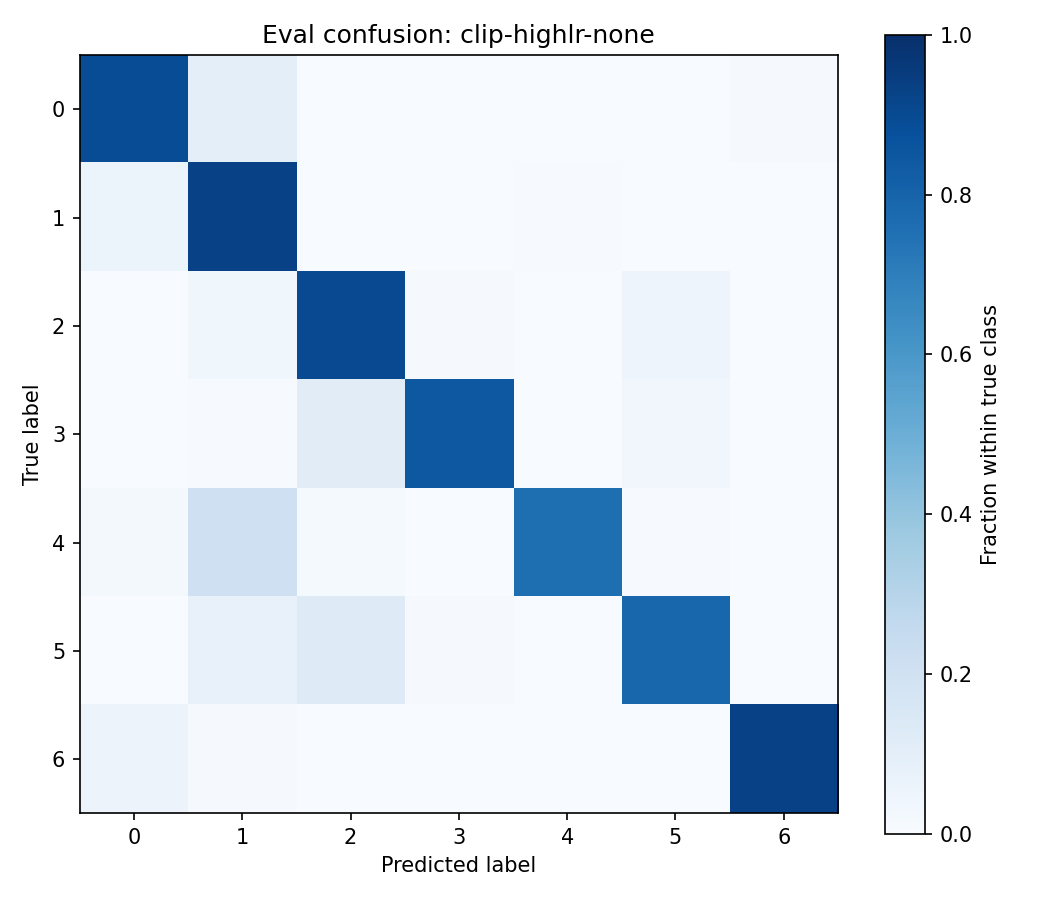

In [20]:
from results_table import load_results
import pandas as pd
records = load_results(out/'results')
pred = pd.read_csv(out/'predictions_eval.csv')
assert list(pred.columns) == ['row_id','pred']
assert len(pred) == 116203 and pred.row_id.is_unique
assert pred.pred.between(0,6).all()
assert all((out/'figures'/f"{r['cfg']['exp_id']}.png").exists() for r in records)
assert all((out/name).exists() for name in ['REPORT.md','experiments.xlsx','eval_result.json','code/lab.ipynb'])
print('16 experiment records; 116203 unique eval predictions; required files exist.')
display(Image(filename=str(out/'figures/confusion_eval.png')))
